## NAME: Souri Rishik Volety
## Reg No: 230968004

### Solved Example: Vacuum Cleaner Agent
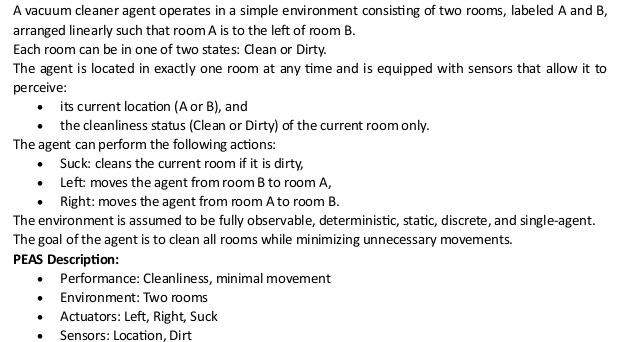

In [1]:
class VacuumAgent:
    def __init__(self):
        self.location = 'A'
        
    def act(self, percept):
        location, status = percept
        if status == 'Dirty':
            return 'Suck'
        elif location == 'A':
            return 'Right'
        else:
            return 'Left'

agent = VacuumAgent()
print(agent.act(('A','Dirty')))

Suck


### Experiment 2: Simple Reflex Agent in a 4-Room Grid Environment
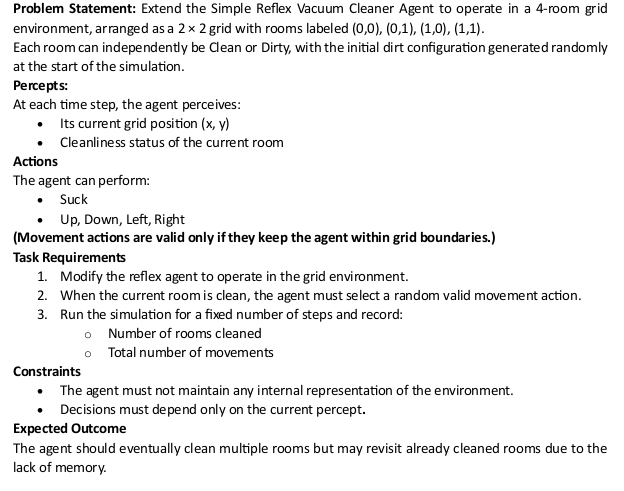

In [2]:
import random

GRID_SIZE = 2
ACTIONS = ["Up", "Down", "Left", "Right"]

environment = {}
for x in range(GRID_SIZE):
    for y in range(GRID_SIZE):
        environment[(x, y)] = random.choice(["Dirty", "Clean"])

agent_position = (random.randint(0, 1), random.randint(0, 1))

rooms_cleaned = 0
movement_count = 0

In [3]:
def get_valid_moves(position):
    x, y = position
    moves = []
    if x > 0:
        moves.append("Left")
    if x < GRID_SIZE - 1:
        moves.append("Right")
    if y > 0:
        moves.append("Down")
    if y < GRID_SIZE - 1:
        moves.append("Up")
    return moves

In [4]:
def move_agent(position, action):
    x, y = position
    if action == "Up":
        return (x, y + 1)
    elif action == "Down":
        return (x, y - 1)
    elif action == "Left":
        return (x - 1, y)
    elif action == "Right":
        return (x + 1, y)
    return position

In [5]:
TIME_STEPS = 20

print("Initial Environment:", environment)
print("Initial Agent Position:", agent_position)

Initial Environment: {(0, 0): 'Clean', (0, 1): 'Dirty', (1, 0): 'Clean', (1, 1): 'Clean'}
Initial Agent Position: (0, 1)


In [6]:
for step in range(TIME_STEPS):
    current_status = environment[agent_position]

    print(f"Step {step + 1}")
    print("Agent Position:", agent_position)
    print("Room Status:", current_status)

    if current_status == "Dirty":
        environment[agent_position] = "Clean"
        rooms_cleaned += 1
        print("Action: Suck")
    else:
        valid_moves = get_valid_moves(agent_position)
        action = random.choice(valid_moves)
        agent_position = move_agent(agent_position, action)
        movement_count += 1
        print("Action:", action)

print("Simulation Complete")
print("Rooms Cleaned:", rooms_cleaned)
print("Total Movements:", movement_count)

Step 1
Agent Position: (0, 1)
Room Status: Dirty
Action: Suck
Step 2
Agent Position: (0, 1)
Room Status: Clean
Action: Down
Step 3
Agent Position: (0, 0)
Room Status: Clean
Action: Right
Step 4
Agent Position: (1, 0)
Room Status: Clean
Action: Up
Step 5
Agent Position: (1, 1)
Room Status: Clean
Action: Down
Step 6
Agent Position: (1, 0)
Room Status: Clean
Action: Up
Step 7
Agent Position: (1, 1)
Room Status: Clean
Action: Left
Step 8
Agent Position: (0, 1)
Room Status: Clean
Action: Right
Step 9
Agent Position: (1, 1)
Room Status: Clean
Action: Down
Step 10
Agent Position: (1, 0)
Room Status: Clean
Action: Up
Step 11
Agent Position: (1, 1)
Room Status: Clean
Action: Down
Step 12
Agent Position: (1, 0)
Room Status: Clean
Action: Left
Step 13
Agent Position: (0, 0)
Room Status: Clean
Action: Right
Step 14
Agent Position: (1, 0)
Room Status: Clean
Action: Left
Step 15
Agent Position: (0, 0)
Room Status: Clean
Action: Up
Step 16
Agent Position: (0, 1)
Room Status: Clean
Action: Right
Step 

### Experiment 3: Model-Based Vacuum Cleaner Agent
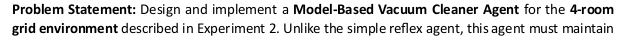
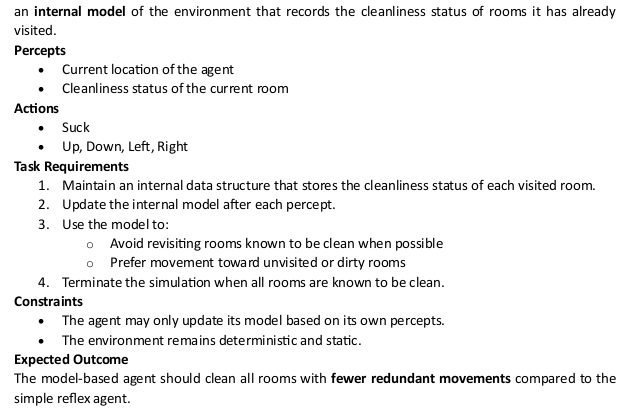

In [7]:
class ModelBasedVacuumAgent:
    def __init__(self):
        self.model = {
            (0, 0): 'Unknown', (0, 1): 'Unknown',
            (1, 0): 'Unknown', (1, 1): 'Unknown'
        }
        self.dims = (2, 2)

    def update_model(self, pos, status):
        self.model[pos] = status

    def get_next_action(self, pos, status):
        self.update_model(pos, status)

        if status == 'Dirty':
            self.model[pos] = 'Clean'
            return 'Suck'

        if all(s == 'Clean' for s in self.model.values()):
            return 'Terminate'

        target = None
        for room, state in self.model.items():
            if state == 'Unknown':
                target = room
                break
        
        if target:
            tx, ty = target
            cx, cy = pos
            if tx > cx: return 'Right'
            if tx < cx: return 'Left'
            if ty > cy: return 'Down'
            if ty < cy: return 'Up'
        
        return 'Terminate'

In [8]:
class Environment:
    def __init__(self):
        self.rooms = {
            (0, 0): 'Dirty', (0, 1): 'Dirty',
            (1, 0): 'Dirty', (1, 1): 'Dirty'
        }
        self.agent_pos = (0, 0)

    def step(self, action):
        if action == 'Suck':
            self.rooms[self.agent_pos] = 'Clean'
        elif action == 'Up' and self.agent_pos[1] > 0:
            self.agent_pos = (self.agent_pos[0], self.agent_pos[1] - 1)
        elif action == 'Down' and self.agent_pos[1] < 1:
            self.agent_pos = (self.agent_pos[0], self.agent_pos[1] + 1)
        elif action == 'Left' and self.agent_pos[0] > 0:
            self.agent_pos = (self.agent_pos[0] - 1, self.agent_pos[1])
        elif action == 'Right' and self.agent_pos[0] < 1:
            self.agent_pos = (self.agent_pos[0] + 1, self.agent_pos[1])
        
        return self.agent_pos, self.rooms[self.agent_pos]

def run_simulation():
    env = Environment()
    agent = ModelBasedVacuumAgent()
    pos, status = env.agent_pos, env.rooms[env.agent_pos]
    
    print(f"Initial State: Rooms {env.rooms}")
    
    while True:
        action = agent.get_next_action(pos, status)
        print(f"Agent at {pos} sees {status}, Action: {action}")
        
        if action == 'Terminate':
            print("Goal Reached: All rooms are clean.")
            break
            
        pos, status = env.step(action)

In [9]:
run_simulation()

Initial State: Rooms {(0, 0): 'Dirty', (0, 1): 'Dirty', (1, 0): 'Dirty', (1, 1): 'Dirty'}
Agent at (0, 0) sees Dirty, Action: Suck
Agent at (0, 0) sees Clean, Action: Down
Agent at (0, 1) sees Dirty, Action: Suck
Agent at (0, 1) sees Clean, Action: Right
Agent at (1, 1) sees Dirty, Action: Suck
Agent at (1, 1) sees Clean, Action: Up
Agent at (1, 0) sees Dirty, Action: Suck
Agent at (1, 0) sees Clean, Action: Terminate
Goal Reached: All rooms are clean.


### 1. Why does the simple reflex agent perform redundant actions in the grid environment?
In a grid environment, a simple reflex agent performs redundant actions primarily because it lacks memory. It bases every decision solely on its current percept (immediate sensory input) and ignores all past perceptions or actions.

### 2. How does the internal model improve agent performance?
An internal model improves agent performance by
allowing it to maintain a persistent memory of the environment, enabling more informed decision-making than simple reflex systems

### 3. Compare the simple reflex and model-based agents in terms of:
### a. Rationality
Model-based agents are generally more rational than simple reflex agents.

### b. Efficiency
Simple reflex agents are more efficient in terms of computational resources and execution speed, while model-based agents are more efficient in terms of achieving the goal state.

### c. Scalability
Simple reflex agents scale better in terms of complexity of rules needed for simple tasks, but model-based agents scale better for complex, real-world problems.

### 4. Would the model-based agent still work correctly in a partially observable environment? Justify.
Yes, a model-based agent works correctly and effectively in a partially observable environment.
A model-based agent works because it uses an
internal state to track and "remember" unobserved parts of the environment based on past percepts and predicted actions.